In [1]:
import torch

# Descobre se o CUDA (sistema da NVIDIA) está disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 O processamento matemático ocorrerá na: {device}") 
# Se tudo estiver certo, ele vai imprimir "cuda"

🔥 O processamento matemático ocorrerá na: cuda


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. DOWNLOAD DOS DADOS
# ==========================================
empresas = ['MSFT', 'GOOGL', 'NVDA', 'META']
# Mude o ano de 2019 para 2023 (Isso pegará o mercado recente e a era da IA)
dados_brutos = yf.download(empresas, start="2023-01-01", end="2026-01-01")['Close']
dados_brutos = dados_brutos.dropna()

# ==========================================
# 2. A MÁGICA DO PROFESSOR: INDICADORES TÉCNICOS
# ==========================================
# Vamos calcular os indicadores para a Microsoft (nossa ação alvo)

# SMA (Média Móvel Simples de 20 dias) - Mostra a tendência média mensal
dados_brutos['MSFT_SMA_20'] = dados_brutos['MSFT'].rolling(window=20).mean()

# EMA (Média Móvel Exponencial de 20 dias) - Dá mais peso aos dias recentes
dados_brutos['MSFT_EMA_20'] = dados_brutos['MSFT'].ewm(span=20, adjust=False).mean()

# RSI (Índice de Força Relativa de 14 dias) - Mostra se a ação está "sobrecomprada" ou "sobrevendida"
delta = dados_brutos['MSFT'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
dados_brutos['MSFT_RSI_14'] = 100 - (100 / (1 + rs))

# Importante: Como calculamos médias de até 20 dias, as 20 primeiras linhas da tabela
# ficarão vazias (NaN) porque não há passado suficiente. Precisamos removê-las.
dados_brutos = dados_brutos.dropna()

print(f"As nossas colunas agora são: {dados_brutos.columns.tolist()}")

# ==========================================
# 3. NORMALIZAÇÃO E JANELA DESLIZANTE
# ==========================================
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(dados_brutos)

# Descobre automaticamente qual é o número da coluna da Microsoft
indice_alvo = dados_brutos.columns.get_loc('MSFT')
print(f"A Microsoft está na coluna de índice: {indice_alvo}")

def criar_sequencias(dados, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados)):
        X.append(dados[i-seq_len:i])
        # Agora ele pega a coluna certa de forma dinâmica!
        y.append(dados[i, indice_alvo])
    return np.array(X), np.array(y)

seq_len = 60
X, y = criar_sequencias(dados_normalizados, seq_len)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ==========================================
# 4. DATASETS PYTORCH
# ==========================================
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TimeSeriesDataset(X_train, y_train)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

print(f"\nNovo Formato do X_train: {X_train.shape} -> (Amostras, Dias, Features)")

[*********************100%***********************]  4 of 4 completed

As nossas colunas agora são: ['GOOGL', 'META', 'MSFT', 'NVDA', 'MSFT_SMA_20', 'MSFT_EMA_20', 'MSFT_RSI_14']
A Microsoft está na coluna de índice: 2

Novo Formato do X_train: (538, 60, 7) -> (Amostras, Dias, Features)


In [3]:
import torch.nn as nn

class Modelo_Hibrido_IA(nn.Module):
    def __init__(self, input_size, hidden_lstm, hidden_gru, output_size):
        super(Modelo_Hibrido_IA, self).__init__()

        # 1. Primeira Camada: LSTM (Foca no longo prazo)
        # Recebe as 4 empresas e gera 'hidden_lstm' características
        self.lstm = nn.LSTM(input_size, hidden_lstm, batch_first=True)

        # 2. Segunda Camada: GRU (Refina o curto prazo)
        # Recebe a saída da LSTM e comprime ainda mais o raciocínio
        self.gru = nn.GRU(hidden_lstm, hidden_gru, batch_first=True)

        # 3. Camada Linear: O Veredito final
        self.fc = nn.Linear(hidden_gru, output_size)

    def forward(self, x):
        # Passo 1: Passa os dados pelas válvulas da LSTM
        saida_lstm, (h_n_lstm, c_n_lstm) = self.lstm(x)

        # Passo 2: A GRU recebe como "entrada" a interpretação da LSTM
        saida_gru, h_n_gru = self.gru(saida_lstm)

        # Passo 3: Pegamos apenas a conclusão do ÚLTIMO dia (índice -1)
        # para não prever o passado, igual explicamos antes!
        out_ultimo_dia = saida_gru[:, -1, :]

        # Passo 4: A regressão linear final para dar o preço da ação
        previsao = self.fc(out_ultimo_dia)

        return previsao

# Recriando a máquina com a nova planta híbrida!
tamanho_entrada = 7
oculto_lstm = 64
oculto_gru = 32 # A GRU costuma ser menor para funilar a informação
tamanho_saida = 1

modelo_robusto = Modelo_Hibrido_IA(tamanho_entrada, oculto_lstm, oculto_gru, tamanho_saida)

print("Nova Arquitetura Híbrida Criada:")
print(modelo_robusto)

Nova Arquitetura Híbrida Criada:
Modelo_Hibrido_IA(
  (lstm): LSTM(7, 64, batch_first=True)
  (gru): GRU(64, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [4]:
import torch.optim as optim

# ==========================================
# CONFIGURAÇÕES DO MOTOR DE APRENDIZADO
# ==========================================
# 1. Função de Perda (Loss Function): O Termômetro de Erro
# O MSELoss (Erro Quadrático Médio) calcula a diferença entre o chute do modelo e o preço real, e eleva ao quadrado.
criterion = nn.MSELoss()

# 2. Otimizador (Optimizer): O Mecânico
# O Adam é o algoritmo que pega o erro, calcula a derivada (gradiente) e ajusta as matrizes de Pesos da LSTM e GRU.
# 'lr' é a Taxa de Aprendizado (Learning Rate): o tamanho do passo que ele dá para corrigir o erro.
optimizer = optim.Adam(modelo_robusto.parameters(), lr=0.001)

# Quantas vezes o modelo vai ler todo o histórico de anos?
epocas = 50

print("Iniciando o treinamento do modelo...\n")

# ==========================================
# O LOOP DE TREINAMENTO MATEMÁTICO
# ==========================================
for epoca in range(epocas):
    modelo_robusto.train() # Avisa o PyTorch que estamos no modo de aprendizado

    erro_acumulado = 0.0

    # O train_loader entrega os tensores em pacotes de 32 dias por vez
    for pacotes_X, pacotes_y in train_loader:

        # Passo 1: Zerar os gradientes (derivadas) do pacote anterior.
        # Se não fizermos isso, a matemática mistura os erros antigos com os novos.
        optimizer.zero_grad()

        # Passo 2: O Chute (Forward Pass)
        # Passamos os 60 dias das 4 empresas pelo modelo
        previsoes = modelo_robusto(pacotes_X)

        # O modelo cospe no formato [32, 1], e nosso gabarito y é [32].
        # Precisamos usar squeeze() para achatar a previsão e deixá-los do mesmo formato para a conta matemática.
        previsoes = previsoes.squeeze()

        # Passo 3: Calcular o Erro (Loss)
        # O quão longe o chute passou da realidade?
        erro = criterion(previsoes, pacotes_y)

        # Passo 4: A Mágica do Cálculo (Backpropagation)
        # O PyTorch calcula a derivada parcial do erro em relação a CADA PESO da LSTM e da GRU.
        erro.backward()

        # Passo 5: O Ajuste
        # O Adam gira as maçanetas matemáticas sutilmente para diminuir o erro na próxima vez.
        optimizer.step()

        erro_acumulado += erro.item()

    # Calculando a média do erro nessa época
    erro_medio = erro_acumulado / len(train_loader)

    # Imprimir o progresso a cada 10 épocas para vermos o modelo ficando inteligente
    if (epoca + 1) % 10 == 0 or epoca == 0:
        print(f'Época [{epoca+1}/{epocas}] | Erro (MSE Loss): {erro_medio:.5f}')

print("\nTreinamento concluído! O modelo agora entende o padrão das ações de IA.")

Iniciando o treinamento do modelo...

Época [1/50] | Erro (MSE Loss): 0.12428
Época [10/50] | Erro (MSE Loss): 0.00159
Época [20/50] | Erro (MSE Loss): 0.00092
Época [30/50] | Erro (MSE Loss): 0.00076
Época [40/50] | Erro (MSE Loss): 0.00074
Época [50/50] | Erro (MSE Loss): 0.00062

Treinamento concluído! O modelo agora entende o padrão das ações de IA.


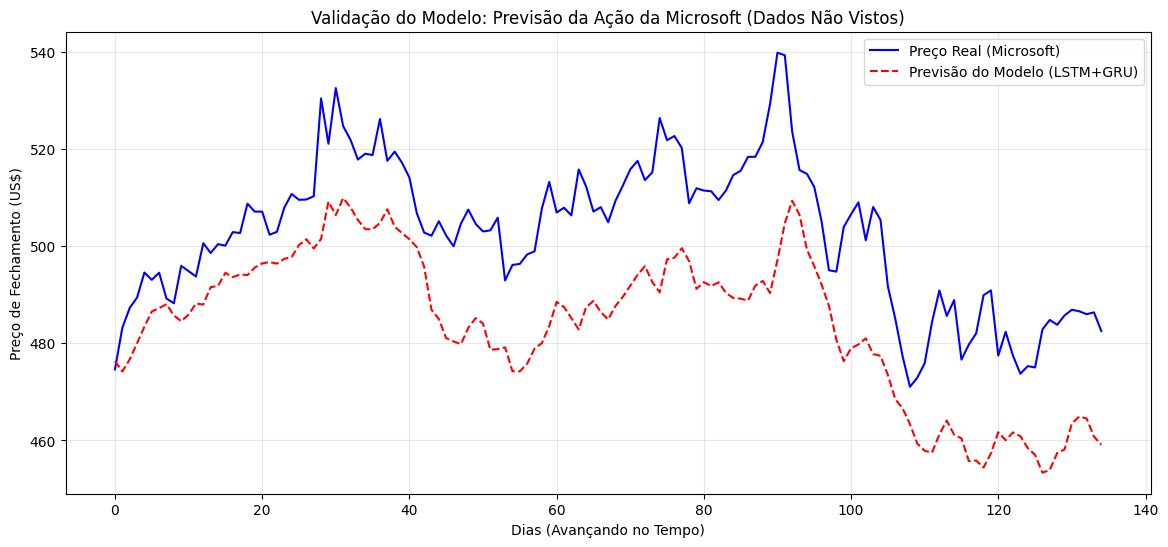

--- Comparação dos últimos 5 dias ---
Dia -1: Real = US$ 482.52 | Previsto = US$ 459.12
Dia -2: Real = US$ 486.37 | Previsto = US$ 460.80
Dia -3: Real = US$ 485.99 | Previsto = US$ 464.53
Dia -4: Real = US$ 486.60 | Previsto = US$ 464.91
Dia -5: Real = US$ 486.91 | Previsto = US$ 463.53


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ==========================================
# PILAR 4: AVALIAÇÃO (TESTE) E GRÁFICOS
# ==========================================
# 1. Colocamos o modelo em modo de avaliação (desliga atualizações de pesos)
modelo_robusto.eval()

previsoes_modelo = []
valores_reais = []

# torch.no_grad() desliga o cálculo de derivadas, economizando memória e deixando super rápido
with torch.no_grad():
    for pacotes_X, pacotes_y in test_loader:
        # O modelo faz as previsões para os dados que ele nunca viu
        chute = modelo_robusto(pacotes_X)

        # Guardamos as previsões e os valores reais em listas
        previsoes_modelo.extend(chute.squeeze().tolist())
        valores_reais.extend(pacotes_y.tolist())

# ==========================================
# A ENGENHARIA REVERSA DA NORMALIZAÇÃO
# ==========================================
# Como o scaler foi treinado com 4 colunas (as 4 empresas), ele exige 4 colunas para desfazer a matemática.
# Vamos criar matrizes falsas cheias de zeros, e colocar a nossa previsão da Microsoft na primeira coluna (índice 0).
matriz_falsa_previsoes = np.zeros((len(previsoes_modelo), 7))
matriz_falsa_previsoes[:, 2] = previsoes_modelo

matriz_falsa_reais = np.zeros((len(valores_reais), 7))
matriz_falsa_reais[:, 2] = valores_reais

# Desfazendo a normalização (De 0 a 1 de volta para US$)
previsoes_em_dolar = scaler.inverse_transform(matriz_falsa_previsoes)[:, 2]
reais_em_dolar = scaler.inverse_transform(matriz_falsa_reais)[:, 2]

# ==========================================
# PLOTANDO O GRÁFICO DE RESULTADOS
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(reais_em_dolar, label='Preço Real (Microsoft)', color='blue', linewidth=1.5)
plt.plot(previsoes_em_dolar, label='Previsão do Modelo (LSTM+GRU)', color='red', linestyle='--', linewidth=1.5)

plt.title('Validação do Modelo: Previsão da Ação da Microsoft (Dados Não Vistos)')
plt.xlabel('Dias (Avançando no Tempo)')
plt.ylabel('Preço de Fechamento (US$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Imprimindo a diferença dos últimos 5 dias
print("--- Comparação dos últimos 5 dias ---")
for i in range(1, 6):
    print(f"Dia {-i}: Real = US$ {reais_em_dolar[-i]:.2f} | Previsto = US$ {previsoes_em_dolar[-i]:.2f}")

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculando MAE e RMSE usando o scikit-learn
mae = mean_absolute_error(reais_em_dolar, previsoes_em_dolar)
rmse = np.sqrt(mean_squared_error(reais_em_dolar, previsoes_em_dolar))

# Calculando o MAPE matematicamente
# Evitamos divisão por zero adicionando um número minúsculo (1e-8) caso o preço real seja 0
mape = np.mean(np.abs((reais_em_dolar - previsoes_em_dolar) / (reais_em_dolar + 1e-8))) * 100

print("=== MÉTRICAS DE DESEMPENHO DO MODELO ===")
print(f"MAE  (Erro Médio Absoluto): US$ {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): US$ {rmse:.2f}")
print(f"MAPE (Erro Percentual): {mape:.2f}%")

=== MÉTRICAS DE DESEMPENHO DO MODELO ===
MAE  (Erro Médio Absoluto): US$ 18.71
RMSE (Raiz do Erro Quadrático): US$ 20.46
MAPE (Erro Percentual): 3.71%


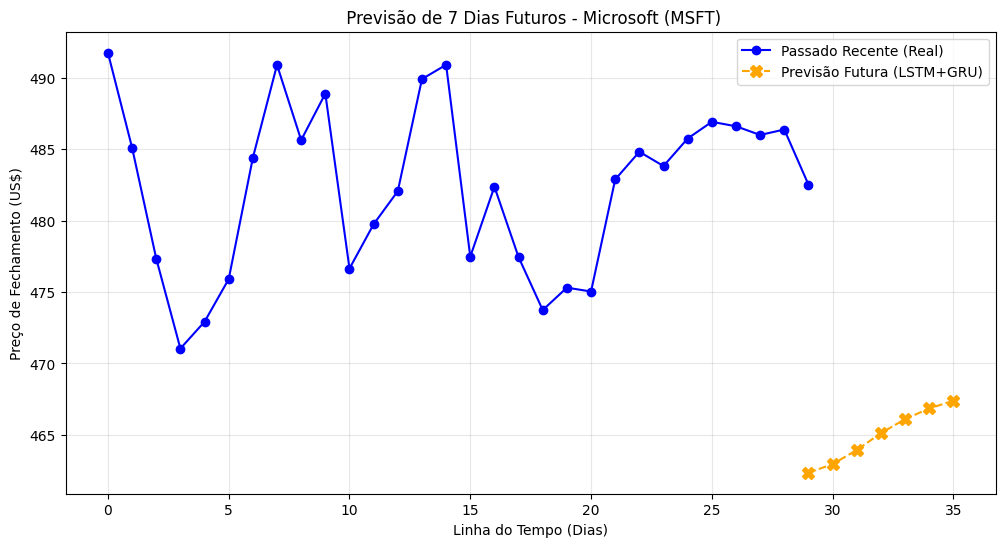

=== PREVISÃO PARA OS PRÓXIMOS 7 DIAS ÚTEIS ===
Dia 1: US$ 462.36
Dia 2: US$ 462.96
Dia 3: US$ 463.94
Dia 4: US$ 465.13
Dia 5: US$ 466.10
Dia 6: US$ 466.85
Dia 7: US$ 467.39


In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ==========================================
# PILAR 5: PREVISÃO DO FUTURO (Inferência)
# ==========================================
modelo_robusto.eval() # Modo de avaliação ligado

# 1. Pegamos a última janela real disponível de 60 dias
# 'dados_normalizados' é aquela matriz gigante de todos os anos que fizemos no Pilar 1
ultima_janela = dados_normalizados[-60:]

# Convertemos para Tensor do PyTorch.
# O unsqueeze(0) adiciona a dimensão do "Lote" (Batch), ficando no formato [1, 60, 4]
tensor_janela = torch.tensor(ultima_janela, dtype=torch.float32).unsqueeze(0)

previsoes_futuras_normalizadas = []
dias_para_prever = 7

# ==========================================
# O LOOP AUTO-REGRESSIVO (Adivinhando o futuro)
# ==========================================
with torch.no_grad():
    for i in range(dias_para_prever):
        # O modelo olha para os 60 dias e chuta o dia seguinte da Microsoft
        previsao_msft = modelo_robusto(tensor_janela)
        valor_previsto = previsao_msft.item()
        previsoes_futuras_normalizadas.append(valor_previsto)

        # Agora montamos os dados do "novo dia" para a próxima rodada do loop.
        # Copiamos os valores das 4 empresas do último dia da nossa janela...
        novo_dia = tensor_janela[:, -1, :].clone()

        # ... e substituímos APENAS a Microsoft (índice 0) pela nossa previsão fresquinha!
        novo_dia[0, 0] = valor_previsto

        # Ajustamos o formato para [1, 1, 4] para podermos grudar no tensor principal
        novo_dia = novo_dia.unsqueeze(1)

        # A mágica do deslocamento:
        # Pegamos do dia 1 em diante (jogando o dia 0 fora) e grudamos o 'novo_dia' no final
        tensor_janela = torch.cat((tensor_janela[:, 1:, :], novo_dia), dim=1)

# ==========================================
# DESFAZENDO A NORMALIZAÇÃO
# ==========================================
# O Scaler precisa de 4 colunas para reverter a matemática. Criamos uma matriz falsa.
matriz_falsa_futuro = np.zeros((dias_para_prever, 7))
matriz_falsa_futuro[:, 2] = previsoes_futuras_normalizadas

# Transformamos os números decimais de volta para Dólares (US$)
previsoes_futuras_dolar = scaler.inverse_transform(matriz_falsa_futuro)[:, 2]

# ==========================================
# PLOTANDO O GRÁFICO (Passado + Futuro)
# ==========================================
# Vamos pegar os últimos 30 dias REAIS para mostrar no gráfico e emendar o futuro neles
ultimos_30_dias_reais = dados_brutos['MSFT'].values[-30:]

plt.figure(figsize=(12, 6))

# Plotando os últimos 30 dias reais (em azul)
plt.plot(range(30), ultimos_30_dias_reais, label='Passado Recente (Real)', marker='o', color='blue')

# Plotando os 7 dias do futuro (em laranja)
# Começamos o gráfico no dia 29 para a linha conectar visualmente
plt.plot(range(29, 29 + dias_para_prever), previsoes_futuras_dolar,
         label='Previsão Futura (LSTM+GRU)', marker='X', color='orange', linestyle='dashed', markersize=8)

plt.title(' Previsão de 7 Dias Futuros - Microsoft (MSFT)')
plt.xlabel('Linha do Tempo (Dias)')
plt.ylabel('Preço de Fechamento (US$)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Imprimindo os valores finais para o seu relatório
print("=== PREVISÃO PARA OS PRÓXIMOS 7 DIAS ÚTEIS ===")
for i, preco in enumerate(previsoes_futuras_dolar, 1):
    print(f"Dia {i}: US$ {preco:.2f}")

 Iniciando o treinamento de 100 modelos independentes...
 Rodada 1/100 concluída.
 Rodada 2/100 concluída.
 Rodada 3/100 concluída.
 Rodada 4/100 concluída.
 Rodada 5/100 concluída.
 Rodada 6/100 concluída.
 Rodada 7/100 concluída.
 Rodada 8/100 concluída.
 Rodada 9/100 concluída.
 Rodada 10/100 concluída.
 Rodada 11/100 concluída.
 Rodada 12/100 concluída.
 Rodada 13/100 concluída.
 Rodada 14/100 concluída.
 Rodada 15/100 concluída.
 Rodada 16/100 concluída.
 Rodada 17/100 concluída.
 Rodada 18/100 concluída.
 Rodada 19/100 concluída.
 Rodada 20/100 concluída.
 Rodada 21/100 concluída.
 Rodada 22/100 concluída.
 Rodada 23/100 concluída.
 Rodada 24/100 concluída.
 Rodada 25/100 concluída.
 Rodada 26/100 concluída.
 Rodada 27/100 concluída.
 Rodada 28/100 concluída.
 Rodada 29/100 concluída.
 Rodada 30/100 concluída.
 Rodada 31/100 concluída.
 Rodada 32/100 concluída.
 Rodada 33/100 concluída.
 Rodada 34/100 concluída.
 Rodada 35/100 concluída.
 Rodada 36/100 concluída.
 Rodada 37/100 c

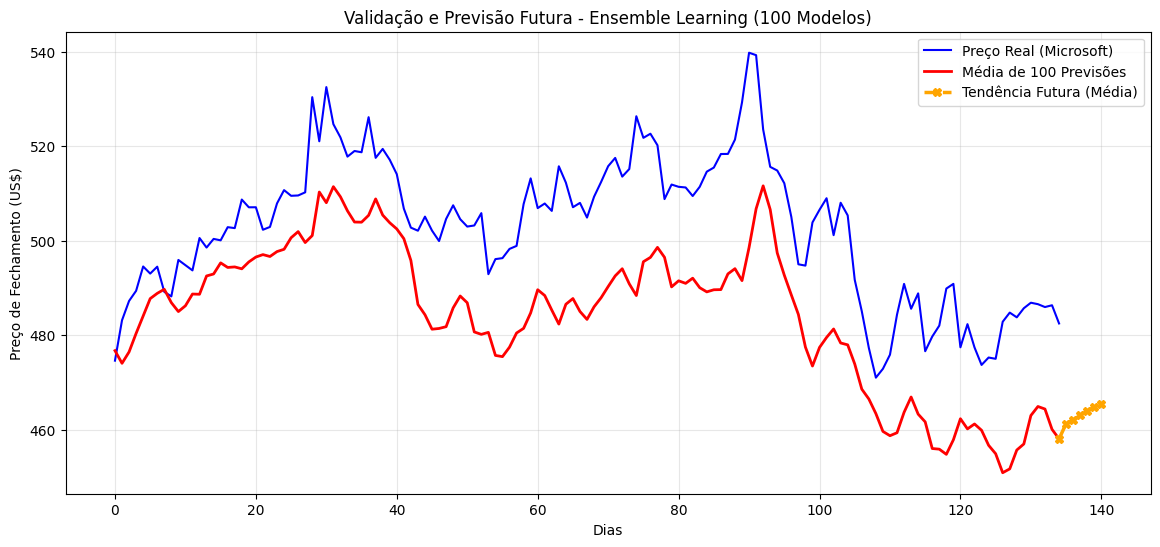


PREVISÃO MÉDIA PARA OS PRÓXIMOS 7 DIAS:
Dia 1: US$ 461.31
Dia 2: US$ 462.10
Dia 3: US$ 463.06
Dia 4: US$ 464.01
Dia 5: US$ 464.85
Dia 6: US$ 465.54
Dia 7: US$ 466.09


In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# CONFIGURAÇÃO DO MEGA TESTE (ENSEMBLE)
# ==========================================
# MUDE PARA 1000 QUANDO FOR RODAR O TESTE DEFINITIVO!
N_RODADAS = 100
epocas_por_rodada = 50

# Listas para guardar o resultado de TODAS as milhares de redes neurais
todas_previsoes_teste = []
todas_previsoes_futuro = []

print(f" Iniciando o treinamento de {N_RODADAS} modelos independentes...")

for rodada in range(N_RODADAS):
    # 1. CRIANDO UMA NOVA REDE TOTALMENTE ZERADA E ALEATÓRIA
    modelo_ensemble = Modelo_Hibrido_IA(input_size=7, hidden_lstm=64, hidden_gru=32, output_size=1).to(device)
    optimizer = optim.Adam(modelo_ensemble.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    # 2. TREINAMENTO
    modelo_ensemble.train()
    for epoca in range(epocas_por_rodada):
        for pacotes_X, pacotes_y in train_loader:
            pacotes_X, pacotes_y = pacotes_X.to(device), pacotes_y.to(device)
            optimizer.zero_grad()
            previsoes = modelo_ensemble(pacotes_X).squeeze()
            erro = criterion(previsoes, pacotes_y)
            erro.backward()
            optimizer.step()

    # 3. TESTE (PILAR 4)
    modelo_ensemble.eval()
    previsoes_modelo = []

    with torch.no_grad():
        for pacotes_X, pacotes_y in test_loader:
            pacotes_X = pacotes_X.to(device)
            chute = modelo_ensemble(pacotes_X)
            previsoes_modelo.extend(chute.cpu().squeeze().tolist())

    # 4. PREVISÃO DO FUTURO (PILAR 5)
    tensor_janela = torch.tensor(dados_normalizados[-60:], dtype=torch.float32).unsqueeze(0)
    previsoes_futuras_normalizadas = []

    with torch.no_grad():
        for i in range(7): # Prever 7 dias
            previsao_msft = modelo_ensemble(tensor_janela.to(device))
            valor_previsto = previsao_msft.cpu().item()
            previsoes_futuras_normalizadas.append(valor_previsto)

            novo_dia = tensor_janela[:, -1, :].clone()
            novo_dia[0, 0] = valor_previsto
            novo_dia = novo_dia.unsqueeze(1)
            tensor_janela = torch.cat((tensor_janela[:, 1:, :], novo_dia), dim=1)

    # 5. DESNORMALIZANDO OS RESULTADOS DESTA RODADA
    # Teste
    matriz_teste = np.zeros((len(previsoes_modelo), 7))
    matriz_teste[:, 2] = previsoes_modelo
    prev_dolar_teste = scaler.inverse_transform(matriz_teste)[:, 2]
    todas_previsoes_teste.append(prev_dolar_teste)

    # Futuro
    matriz_futuro = np.zeros((7, 7))
    matriz_futuro[:, 2] = previsoes_futuras_normalizadas
    prev_dolar_futuro = scaler.inverse_transform(matriz_futuro)[:, 2]
    todas_previsoes_futuro.append(prev_dolar_futuro)

    # Print para você saber que o computador não travou!
    print(f" Rodada {rodada+1}/{N_RODADAS} concluída.")

# ==========================================
# O PODER DA MULTIDÃO: CALCULANDO A MÉDIA
# ==========================================
# np.mean com axis=0 pega todas as 1000 linhas geradas e cria uma única linha média perfeita
media_previsoes_teste = np.mean(todas_previsoes_teste, axis=0)
media_previsoes_futuro = np.mean(todas_previsoes_futuro, axis=0)

# (Reaproveitamos a variável valores_reais do seu Pilar 4 original para as métricas)
mae_final = mean_absolute_error(reais_em_dolar, media_previsoes_teste)
rmse_final = np.sqrt(mean_squared_error(reais_em_dolar, media_previsoes_teste))
mape_final = np.mean(np.abs((reais_em_dolar - media_previsoes_teste) / (reais_em_dolar + 1e-8))) * 100

print("\n" + "="*50)
print(f" RESULTADO FINAL DA MÉDIA DE {N_RODADAS} REDES NEURAIS ")
print("="*50)
print(f"MAE  (Erro Médio Absoluto): US$ {mae_final:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): US$ {rmse_final:.2f}")
print(f"MAPE (Erro Percentual): {mape_final:.2f}%")
print("="*50)

# ==========================================
# PLOTANDO O GRÁFICO FINAL DEFINITIVO
# ==========================================
plt.figure(figsize=(14, 6))

# 1. Gráfico de Validação (Passado)
plt.plot(reais_em_dolar, label='Preço Real (Microsoft)', color='blue', linewidth=1.5)
plt.plot(media_previsoes_teste, label=f'Média de {N_RODADAS} Previsões', color='red', linestyle='-', linewidth=2)

# 2. Emendando o Futuro no Gráfico
ultimo_dia_teste = len(reais_em_dolar) - 1
eixo_x_futuro = range(ultimo_dia_teste, ultimo_dia_teste + 7)

# Para a linha conectar, o primeiro ponto do futuro será o último ponto previsto no teste
linha_futura_conectada = [media_previsoes_teste[-1]] + list(media_previsoes_futuro[:-1])

plt.plot(eixo_x_futuro, linha_futura_conectada, label='Tendência Futura (Média)', color='orange', linestyle='dashed', linewidth=2.5, marker='X')

plt.title(f'Validação e Previsão Futura - Ensemble Learning ({N_RODADAS} Modelos)')
plt.xlabel('Dias')
plt.ylabel('Preço de Fechamento (US$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nPREVISÃO MÉDIA PARA OS PRÓXIMOS 7 DIAS:")
for i, preco in enumerate(media_previsoes_futuro, 1):
    print(f"Dia {i}: US$ {preco:.2f}")

abertura e fechamento
catalogo de dados yahoo
